In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
# Load the heart disease dataset
# Using the Cleveland database which is most commonly used
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Column names
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# na_values='?' → tells Pandas that ? means missing value.
heart_data = pd.read_csv(url, names=column_names, na_values='?')

print(f"Dataset shape: {heart_data.shape}")
print("\nFirst few rows:")
heart_data.head()

Dataset shape: (303, 14)

First few rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# age      → Patient's age
# sex      → Patient's sex (1 = male, 0 = female)
# cp       → Type of chest pain
# trestbps → Resting blood pressure
# chol     → Cholesterol level
# fbs      → Fasting blood sugar > 120 mg/dl (1 = yes, 0 = no)
# restecg  → Resting ECG result
# thalach  → Maximum heart rate reached
# exang    → Exercise-induced chest pain (1 = yes, 0 = no)
# oldpeak  → ST depression caused by exercise
# slope    → Slope of the ST segment
# ca       → Number of major vessels seen by fluoroscopy
# thal     → Thalassemia test result
# target   → Heart disease (0 = no, 1–4 = yes/severity)

In [4]:
# Dataset information
print("Dataset Info:")
print(heart_data.info())
print("\nStatistical Summary:")
print(heart_data.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Statistical Summary:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.6798

In [5]:
print("\nMissing Values:")
print(heart_data.isnull().sum())


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [9]:
# Handle missing values
print(f"Rows before dropping missing values: {heart_data.shape[0]}")
heart_data.dropna(inplace=True)
print(f"Rows after dropping missing values: {len(heart_data)}")

Rows before dropping missing values: 303
Rows after dropping missing values: 297


In [13]:
# Convert target to binary (0: no disease, 1: disease present)
heart_data['target']=(heart_data['target'] > 0 ).astype(int)

print("Target distribution:")
print(heart_data['target'].value_counts())
print(f"\nPercentage with heart disease : {heart_data['target'].mean()*100:.2f}%")

Target distribution:
target
0    160
1    137
Name: count, dtype: int64

Percentage with heart disease : 46.13%


Text(0, 0.5, 'Age')

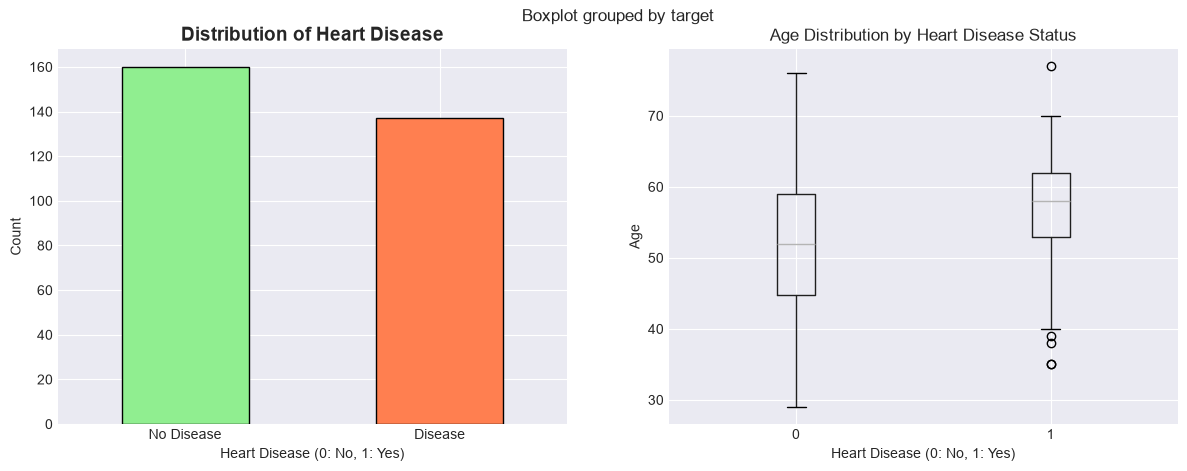

In [22]:
# Visualize target distribution
fig,axes=plt.subplots(1,2,figsize=(14,5))

heart_data['target'].value_counts().plot(kind='bar',ax=axes[0],color=['lightgreen', 'coral'], edgecolor='black')
axes[0].set_title('Distribution of Heart Disease', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease (0: No, 1: Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)

heart_data.boxplot(column='age',ax=axes[1],by='target')
axes[1].set_title('Age Distribution by Heart Disease Status')
axes[1].set_xlabel('Heart Disease (0: No, 1: Yes)')
axes[1].set_ylabel('Age')


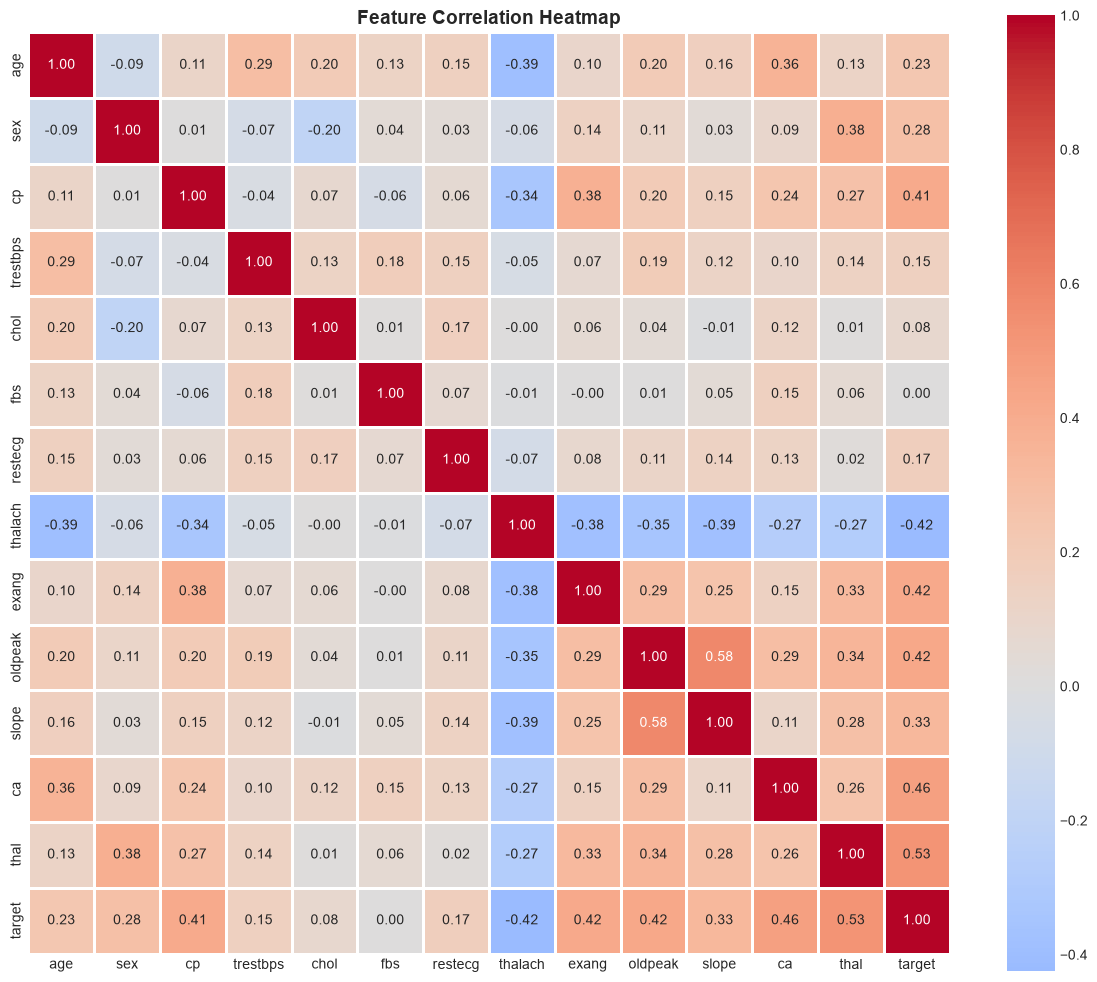

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix=heart_data.corr()
sns.heatmap(correlation_matrix 
            ,annot=True # show values inside the cell
            ,fmt='.2f' # show values with 2 decimal places
            ,cmap='coolwarm',
            center=0,# center the color scale at zero
            square=True, # make cells square 
              linewidths=1 # add lines between cells
              )
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

In [32]:
# Separate features and target
X = heart_data.drop(columns=['target'])
y = heart_data['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {X.columns.tolist()}")

Features shape: (297, 13)
Target shape: (297,)

Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [37]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 237
Test set size: 60


In [ ]:
# Feature scaling (optional for tree-based models but good practice)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # it return ndarray so you loss the name of columns
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Features scaled successfully!")

(237, 13)
Features scaled successfully!


In [40]:
# Create and train unpruned decision tree
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

# Predictions
y_pred_train_unpruned = dt_unpruned.predict(X_train)
y_pred_test_unpruned = dt_unpruned.predict(X_test)

# Evaluate
train_acc_unpruned = accuracy_score(y_train, y_pred_train_unpruned)
test_acc_unpruned = accuracy_score(y_test, y_pred_test_unpruned)

print("Unpruned Decision Tree:")
print(f"  Training Accuracy: {train_acc_unpruned:.4f}")
print(f"  Test Accuracy: {test_acc_unpruned:.4f}")
print(f"  Tree Depth: {dt_unpruned.get_depth()}")
print(f"  Number of Leaves: {dt_unpruned.get_n_leaves()}")

Unpruned Decision Tree:
  Training Accuracy: 1.0000
  Test Accuracy: 0.7000
  Tree Depth: 8
  Number of Leaves: 40


In [41]:
# Create and train pruned decision tree
dt_pruned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,# does the node have at least 20 sample if yes i can split it
    min_samples_leaf=10, # after i split , will each resulting child have at least 10 sample 
    random_state=42
)
dt_pruned.fit(X_train, y_train)

# Predictions
y_pred_train_pruned = dt_pruned.predict(X_train)
y_pred_test_pruned = dt_pruned.predict(X_test)

# Evaluate
train_acc_pruned = accuracy_score(y_train, y_pred_train_pruned)
test_acc_pruned = accuracy_score(y_test, y_pred_test_pruned)

print("Pruned Decision Tree:")
print(f"  Training Accuracy: {train_acc_pruned:.4f}")
print(f"  Test Accuracy: {test_acc_pruned:.4f}")
print(f"  Tree Depth: {dt_pruned.get_depth()}")
print(f"  Number of Leaves: {dt_pruned.get_n_leaves()}")

Pruned Decision Tree:
  Training Accuracy: 0.8565
  Test Accuracy: 0.7667
  Tree Depth: 5
  Number of Leaves: 13


In [42]:
# Compare overfitting
print("\nOverfitting Analysis:")
print(f"Unpruned Tree - Gap: {train_acc_unpruned - test_acc_unpruned:.4f}")
print(f"Pruned Tree - Gap: {train_acc_pruned - test_acc_pruned:.4f}")


Overfitting Analysis:
Unpruned Tree - Gap: 0.3000
Pruned Tree - Gap: 0.0899


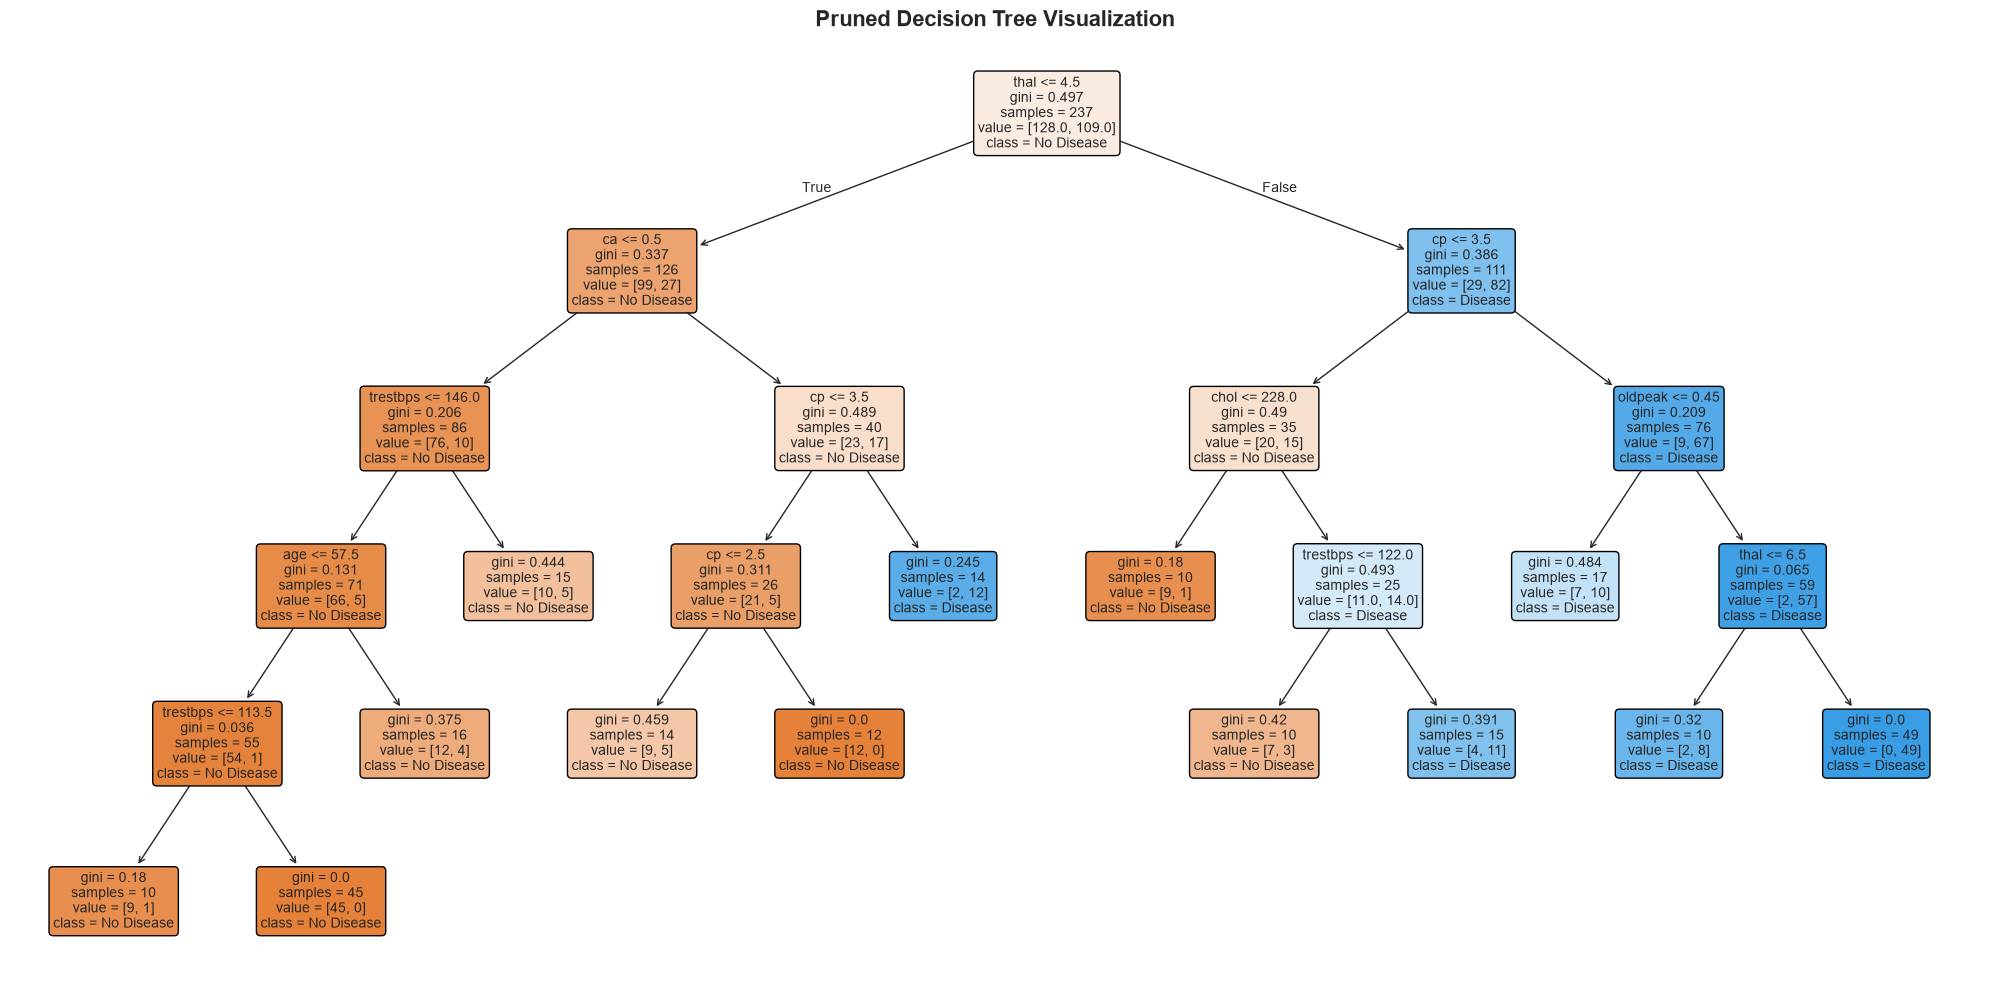

In [48]:
# Visualize pruned decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_pruned,feature_names=X.columns, class_names=['No Disease','Disease'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Pruned Decision Tree Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()


In [49]:
# Get feature importance
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_pruned.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Decision Tree):")
print(feature_importance_dt)

Feature Importance (Decision Tree):
     Feature  Importance
12      thal    0.472488
2         cp    0.278529
11        ca    0.074226
3   trestbps    0.058890
9    oldpeak    0.053752
4       chol    0.043114
0        age    0.019000
1        sex    0.000000
5        fbs    0.000000
8      exang    0.000000
7    thalach    0.000000
6    restecg    0.000000
10     slope    0.000000


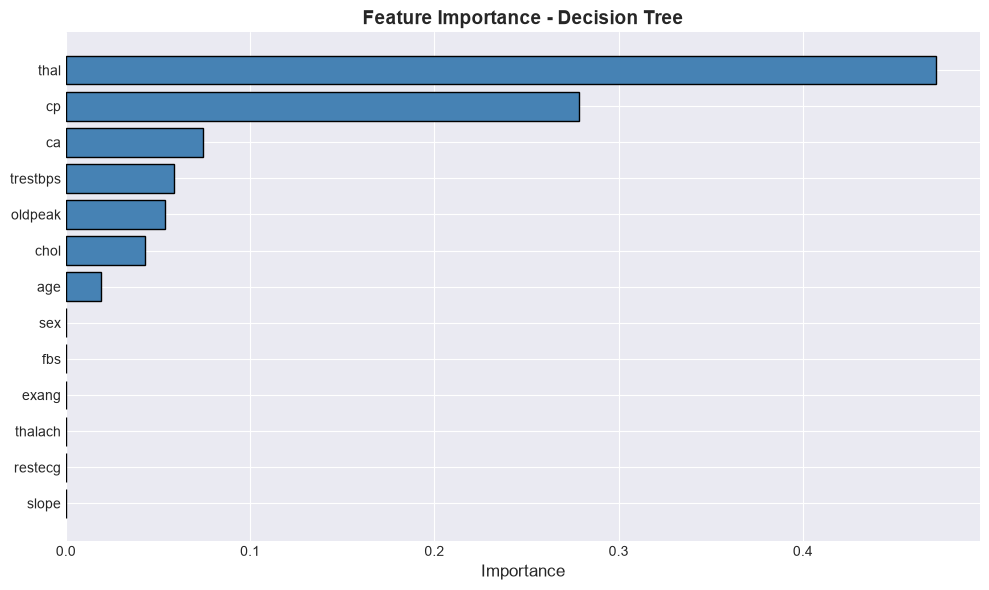

In [52]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_dt['Feature'], feature_importance_dt['Importance'], 
         color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

In [53]:
# Define parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Grid search
print("Performing Grid Search for Decision Tree...")
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_dt.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_dt.best_params_}")
print(f"Best cross-validation score: {grid_search_dt.best_score_:.4f}")

Performing Grid Search for Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best cross-validation score: 0.8137


In [54]:
# Evaluate best decision tree
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

acc_best_dt = accuracy_score(y_test, y_pred_best_dt)
f1_best_dt = f1_score(y_test, y_pred_best_dt)

print("\nBest Decision Tree Performance:")
print(f"  Test Accuracy: {acc_best_dt:.4f}")
print(f"  Test F1-Score: {f1_best_dt:.4f}")


Best Decision Tree Performance:
  Test Accuracy: 0.7667
  Test F1-Score: 0.7407


In [57]:
# Create and train random forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1] # give me prob of having heart disease to each patient


# Evaluate
train_acc_rf = accuracy_score(y_train, y_pred_train_rf)
test_acc_rf = accuracy_score(y_test, y_pred_test_rf)
test_precision_rf = precision_score(y_test, y_pred_test_rf)
test_recall_rf = recall_score(y_test, y_pred_test_rf)
test_f1_rf = f1_score(y_test, y_pred_test_rf)

print("Random Forest Performance:")
print(f"  Training Accuracy: {train_acc_rf:.4f}")
print(f"  Test Accuracy: {test_acc_rf:.4f}")
print(f"  Test Precision: {test_precision_rf:.4f}")
print(f"  Test Recall: {test_recall_rf:.4f}")
print(f"  Test F1-Score: {test_f1_rf:.4f}")

Random Forest Performance:
  Training Accuracy: 0.9747
  Test Accuracy: 0.8667
  Test Precision: 0.8846
  Test Recall: 0.8214
  Test F1-Score: 0.8519


In [58]:
# Get feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance_rf)

Feature Importance (Random Forest):
     Feature  Importance
2         cp    0.156692
12      thal    0.138874
7    thalach    0.114321
9    oldpeak    0.112682
11        ca    0.110378
0        age    0.080033
4       chol    0.074992
3   trestbps    0.068651
10     slope    0.051874
8      exang    0.038668
1        sex    0.023231
6    restecg    0.022547
5        fbs    0.007057


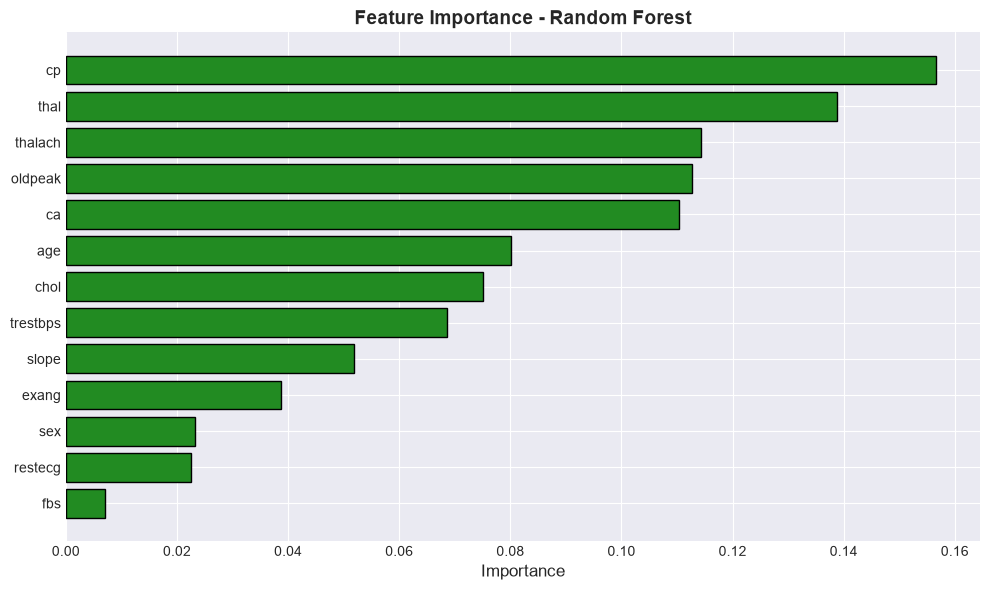

In [59]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], 
         color='forestgreen', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

In [60]:
# Test different numbers of trees
n_estimators_list = [10, 25, 50, 100, 150, 200, 300]
train_scores = []
test_scores = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    
    train_scores.append(rf_temp.score(X_train, y_train))
    test_scores.append(rf_temp.score(X_test, y_test))
    
    print(f"n_estimators={n:3d}: Train={train_scores[-1]:.4f}, Test={test_scores[-1]:.4f}")

n_estimators= 10: Train=0.9831, Test=0.8333
n_estimators= 25: Train=1.0000, Test=0.8167
n_estimators= 50: Train=1.0000, Test=0.8500
n_estimators=100: Train=1.0000, Test=0.8500
n_estimators=150: Train=1.0000, Test=0.8667
n_estimators=200: Train=1.0000, Test=0.8667
n_estimators=300: Train=1.0000, Test=0.8667


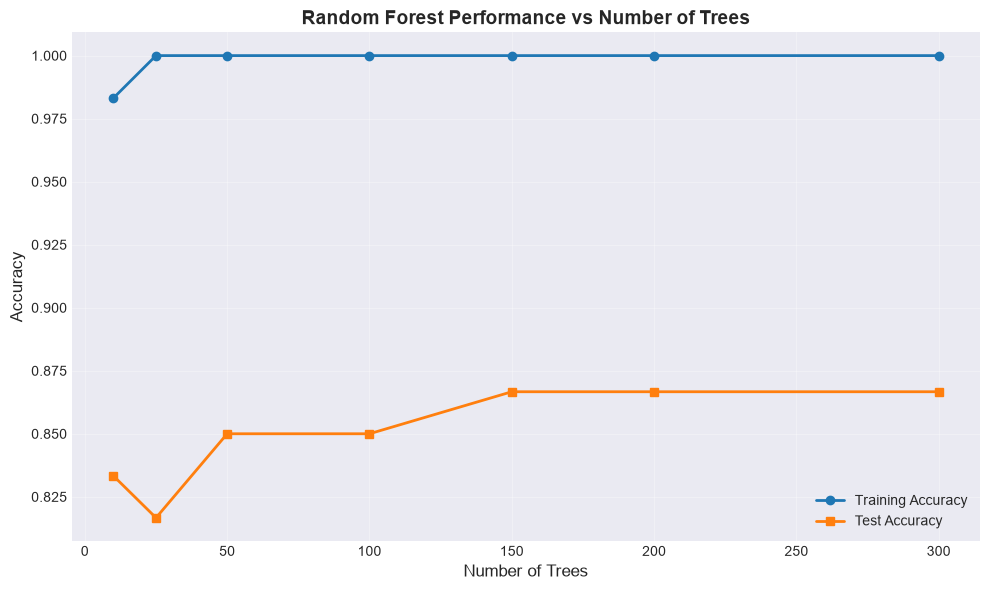

In [61]:
# Plot the effect of number of trees
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_scores, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(n_estimators_list, test_scores, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Random Forest Performance vs Number of Trees', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

In [62]:
# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search
print("Performing Grid Search for Random Forest...")
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validation score: {grid_search_rf.best_score_:.4f}")

Performing Grid Search for Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.8475


In [63]:
# Evaluate best random forest
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

acc_best_rf = accuracy_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)

print("\nBest Random Forest Performance:")
print(f"  Test Accuracy: {acc_best_rf:.4f}")
print(f"  Test F1-Score: {f1_best_rf:.4f}")


Best Random Forest Performance:
  Test Accuracy: 0.8333
  Test F1-Score: 0.8077


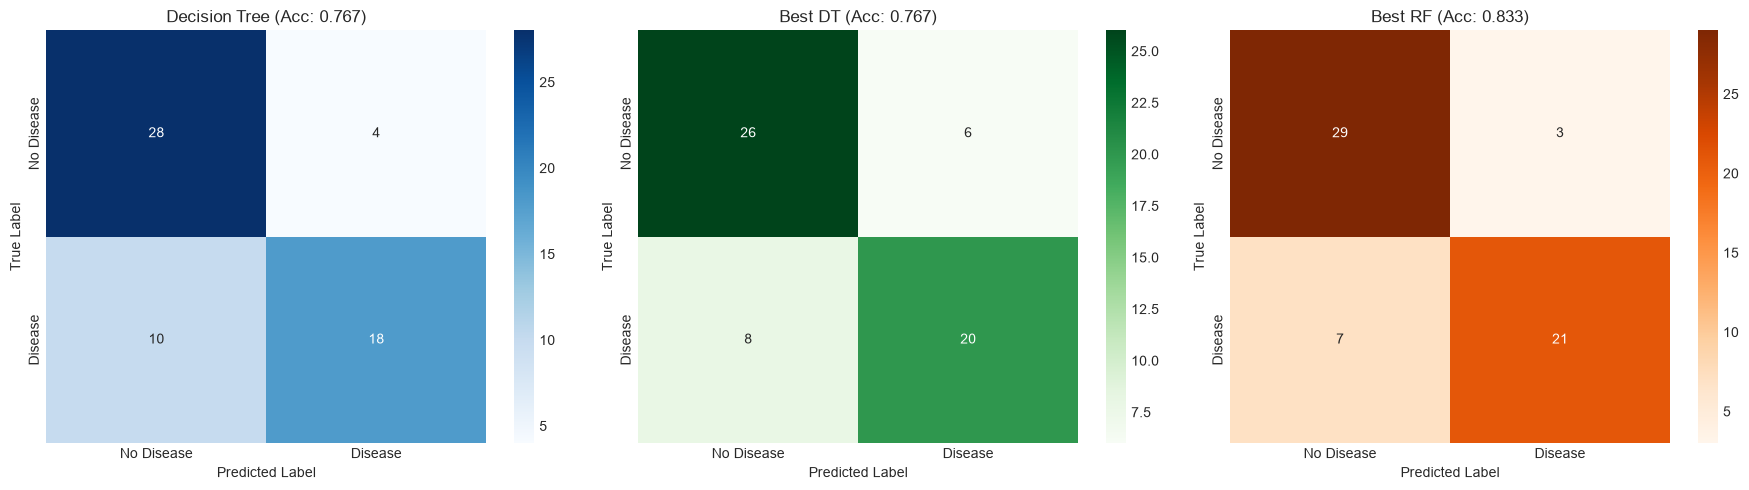

In [64]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree (Pruned)
cm_dt = confusion_matrix(y_test, y_pred_test_pruned)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title(f'Decision Tree (Acc: {test_acc_pruned:.3f})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Decision Tree (Best)
cm_best_dt = confusion_matrix(y_test, y_pred_best_dt)
sns.heatmap(cm_best_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[1].set_title(f'Best DT (Acc: {acc_best_dt:.3f})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Random Forest (Best)
cm_rf = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[2].set_title(f'Best RF (Acc: {acc_best_rf:.3f})')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()

In [65]:
# Performance comparison table
comparison_data = {
    'Model': ['DT Unpruned', 'DT Pruned', 'Best DT', 'RF Default', 'Best RF'],
    'Train Accuracy': [train_acc_unpruned, train_acc_pruned, 
                       best_dt.score(X_train, y_train), train_acc_rf, 
                       best_rf.score(X_train, y_train)],
    'Test Accuracy': [test_acc_unpruned, test_acc_pruned, acc_best_dt, 
                     test_acc_rf, acc_best_rf],
    'Test F1-Score': [f1_score(y_test, y_pred_test_unpruned), 
                     f1_score(y_test, y_pred_test_pruned),
                     f1_best_dt, test_f1_rf, f1_best_rf]

}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL PERFORMANCE COMPARISON
      Model  Train Accuracy  Test Accuracy  Test F1-Score
DT Unpruned        1.000000       0.700000       0.666667
  DT Pruned        0.856540       0.766667       0.720000
    Best DT        0.869198       0.766667       0.740741
 RF Default        0.974684       0.866667       0.851852
    Best RF        0.902954       0.833333       0.807692


In [66]:
# Classification reports
print("\nClassification Report - Best Decision Tree:")
print("="*70)
print(classification_report(y_test, y_pred_best_dt, 
                          target_names=['No Disease', 'Disease']))

print("\nClassification Report - Best Random Forest:")
print("="*70)
print(classification_report(y_test, y_pred_best_rf, 
                          target_names=['No Disease', 'Disease']))


Classification Report - Best Decision Tree:
              precision    recall  f1-score   support

  No Disease       0.76      0.81      0.79        32
     Disease       0.77      0.71      0.74        28

    accuracy                           0.77        60
   macro avg       0.77      0.76      0.76        60
weighted avg       0.77      0.77      0.77        60


Classification Report - Best Random Forest:
              precision    recall  f1-score   support

  No Disease       0.81      0.91      0.85        32
     Disease       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60

